In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
subjects = ["math score", "reading score", "writing score"]

for sub in subjects:
    print(sub)
    print("Mean:", df[sub].mean())
    print("Median:", df[sub].median())
    print("Mode:", df[sub].mode()[0])
    print("Std:", df[sub].std())
    print("Min:", df[sub].min())
    print("Max:", df[sub].max())
    print()

math score
Mean: 66.089
Median: 66.0
Mode: 65
Std: 15.16308009600945
Min: 0
Max: 100

reading score
Mean: 69.169
Median: 70.0
Mode: 72
Std: 14.600191937252216
Min: 17
Max: 100

writing score
Mean: 68.054
Median: 69.0
Mode: 74
Std: 15.19565701086965
Min: 10
Max: 100



In [5]:
df.groupby("gender")[subjects].mean()
df.groupby("parental level of education")[subjects].mean()

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [8]:

# 2. Show all problems found (info(), missing values, duplicates, outliers, etc.).

df = pd.read_csv("StudentsPerformance.csv")

# Add missing values
df.loc[0:10, "math score"] = np.nan

# Add duplicates
df = pd.concat([df, df.iloc[:5]])

# Add outliers
df.loc[20, "math score"] = 300

df.to_csv("messy_students.csv", index=False)

In [9]:
df_messy= pd.read_csv("messy_students.csv")
df_messy

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,NaN,72,74
1,female,group C,some college,standard,completed,NaN,90,88
2,female,group B,master's degree,standard,none,NaN,95,93
3,male,group A,associate's degree,free/reduced,none,NaN,57,44
4,male,group C,some college,standard,none,NaN,78,75
...,...,...,...,...,...,...,...,...
1000,female,group B,bachelor's degree,standard,none,NaN,72,74
1001,female,group C,some college,standard,completed,NaN,90,88
1002,female,group B,master's degree,standard,none,NaN,95,93
1003,male,group A,associate's degree,free/reduced,none,NaN,57,44


In [10]:
print(df_messy.info())

print(df_messy.isnull().sum())

print("Duplicates:", df_messy.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1005 non-null   str    
 1   race/ethnicity               1005 non-null   str    
 2   parental level of education  1005 non-null   str    
 3   lunch                        1005 non-null   str    
 4   test preparation course      1005 non-null   str    
 5   math score                   989 non-null    float64
 6   reading score                1005 non-null   int64  
 7   writing score                1005 non-null   int64  
dtypes: float64(1), int64(2), str(5)
memory usage: 62.9 KB
None
gender                          0
race/ethnicity                  0
parental level of education     0
lunch                           0
test preparation course         0
math score                     16
reading score                   0
writing score          

In [11]:
Q1 = df_messy["math score"].quantile(0.25)
Q3 = df_messy["math score"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_messy[(df_messy["math score"] < lower) | (df_messy["math score"] > upper)]

print(outliers)

     gender race/ethnicity parental level of education         lunch  \
17   female        group B            some high school  free/reduced   
20     male        group D                 high school      standard   
59   female        group C            some high school  free/reduced   
145  female        group C                some college  free/reduced   
338  female        group B            some high school  free/reduced   
466  female        group D          associate's degree  free/reduced   
787  female        group B                some college      standard   
842  female        group B                 high school  free/reduced   
980  female        group B                 high school  free/reduced   

    test preparation course  math score  reading score  writing score  
17                     none        18.0             32             28  
20                     none       300.0             69             63  
59                     none         0.0             17         

In [12]:
df_messy["math score"] = df_messy["math score"].fillna(df_messy["math score"].mean())
df_messy = df_messy[df_messy["math score"] <= upper]
df_cleaned = df_messy.drop_duplicates()
df_cleaned.to_csv("cleaned_students.csv", index=False)

In [13]:
# Load the dataset after cleaning and show the information to confirm the cleaning process.
df_cleaned = pd.read_csv("cleaned_students.csv")




In [14]:
print("cleaned_data")
print(df_cleaned.info())

cleaned_data
<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       999 non-null    str    
 1   race/ethnicity               999 non-null    str    
 2   parental level of education  999 non-null    str    
 3   lunch                        999 non-null    str    
 4   test preparation course      999 non-null    str    
 5   math score                   999 non-null    float64
 6   reading score                999 non-null    int64  
 7   writing score                999 non-null    int64  
dtypes: float64(1), int64(2), str(5)
memory usage: 62.6 KB
None


In [ ]:
print(df_cleaned.groupby("gender")[subjects].mean())

In [15]:
print(df_cleaned.groupby("race/ethnicity")[subjects].mean())

                math score  reading score  writing score
race/ethnicity                                          
group A          61.846514      64.674157      62.674157
group B          63.447571      67.352632      65.600000
group C          64.451471      69.103448      67.827586
group D          67.376781      70.034483      70.172414
group E          73.821429      73.028571      71.407143


In [16]:
print(df_cleaned.groupby("test preparation course")[subjects].mean())

                         math score  reading score  writing score
test preparation course                                          
completed                 69.634132      73.893855      74.418994
none                      64.135285      66.530421      64.507020


In [17]:
corr = df_cleaned[subjects].corr()

print(corr)

               math score  reading score  writing score
math score       1.000000       0.810831       0.794250
reading score    0.810831       1.000000       0.954647
writing score    0.794250       0.954647       1.000000


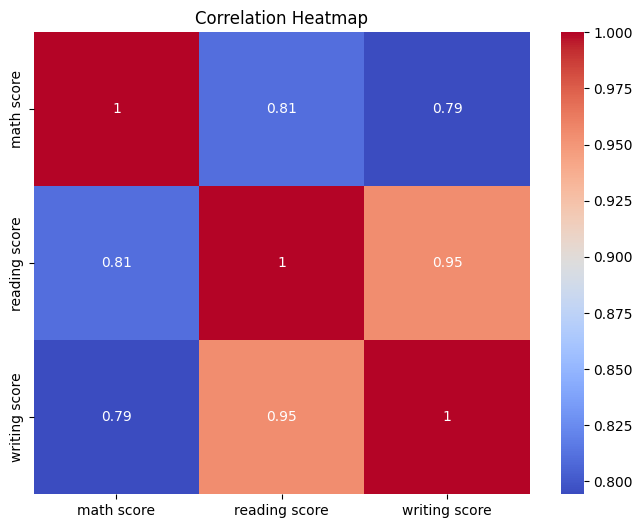

In [18]:
plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

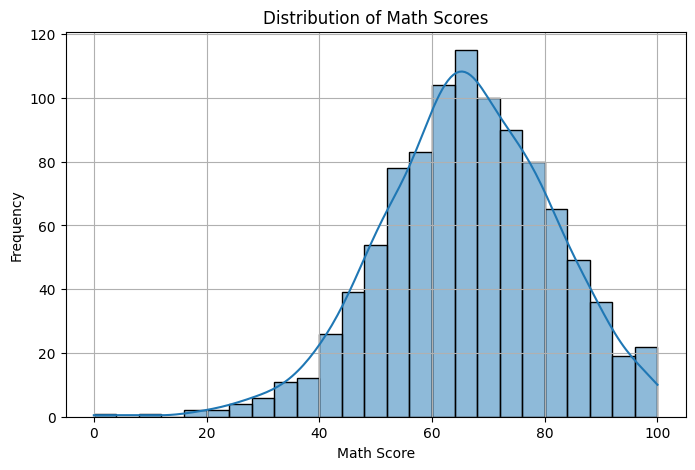

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(df_cleaned["math score"], kde=True)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

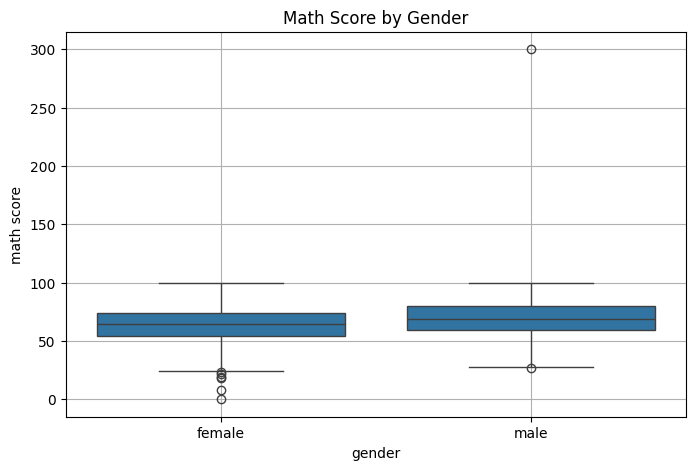

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="gender", y="math score", data=df_cleaned)

plt.title("Math Score by Gender")
plt.grid(True)

plt.show()

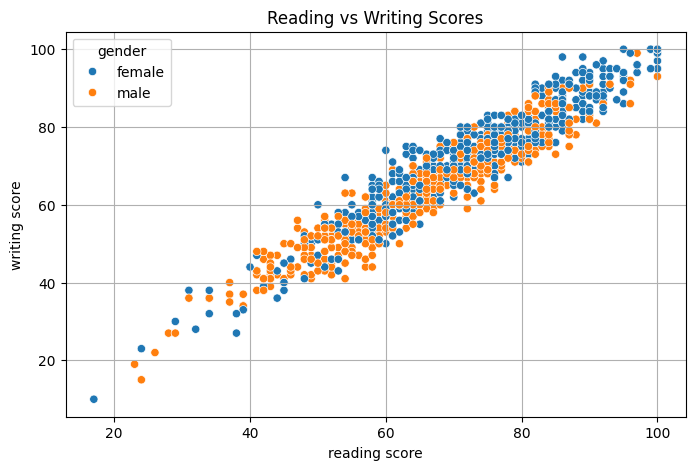

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x="reading score", y="writing score", hue="gender", data=df_cleaned)

plt.title("Reading vs Writing Scores")
plt.grid(True)

plt.show()

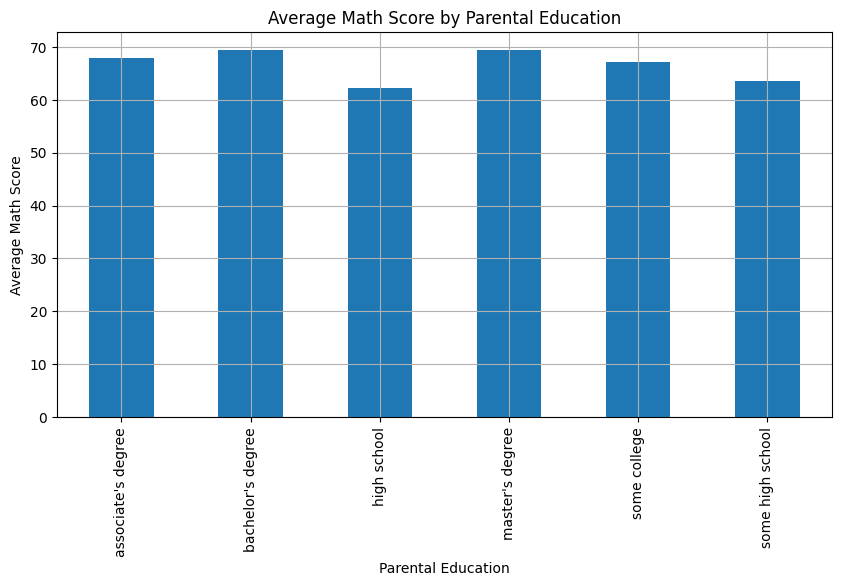

In [23]:
avg_math = df_cleaned.groupby("parental level of education")["math score"].mean()

avg_math.plot(kind="bar", figsize=(10, 5))

plt.title("Average Math Score by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Average Math Score")
plt.grid(True)

plt.show()

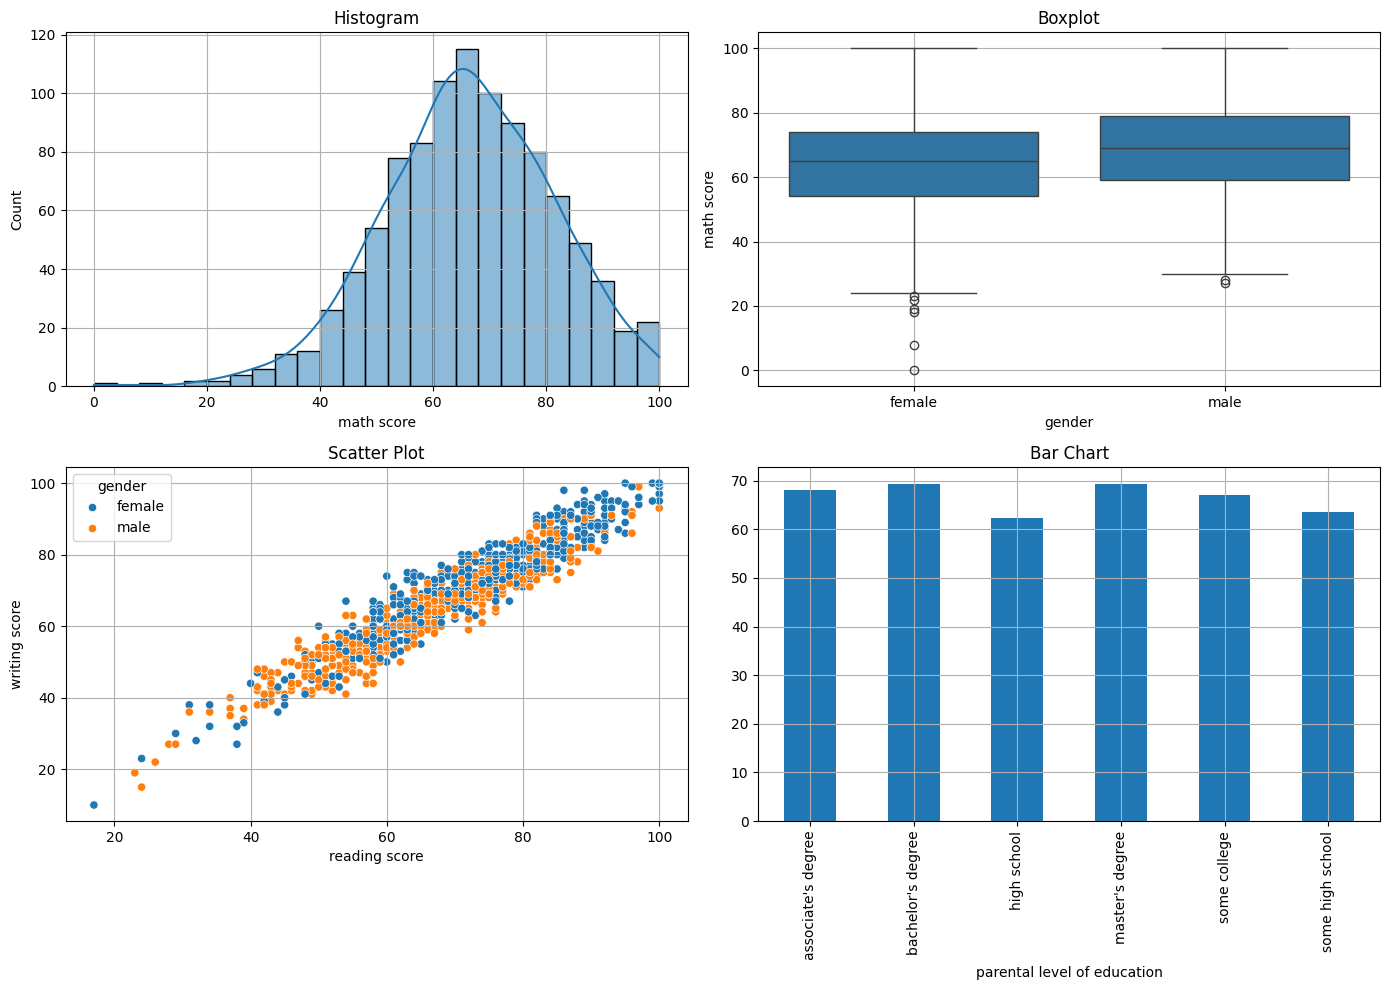

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
sns.histplot(df_cleaned["math score"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Histogram")

# Boxplot
sns.boxplot(x="gender", y="math score", data=df_cleaned, ax=axes[0, 1])
axes[0, 1].set_title("Boxplot")

# Scatterplot
sns.scatterplot(
    x="reading score", y="writing score", hue="gender", data=df_cleaned, ax=axes[1, 0]
)
axes[1, 0].set_title("Scatter Plot")

# Bar chart
avg_math.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Bar Chart")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()

plt.savefig("best_visualization.png")

plt.show()